# Basic Simulation Evaluation  
**Simulation Period:** 2016-05-17 -> 2016-06-04

## Evaluation Metrics
| # | Metric | Definition |
|---|--------|------------|
| 1 | **Average Cycle Time** | Mean time to finish a process instance |
| 2 | **Average Resource Occupation** | Mean share the resources are working during their availabilities |
| 3 | **(Weighted) Resource Fairness** | Mean deviation from the average resource occupation |

Followed by **Management Question**: *"Management wants to fire two employees, which ones and what is the impact?"*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

BASE = Path('..')
COLORS = {'basic': "#2870D5", 'advanced': "#DD528A"}

# Simulation period constants
SIM_START = datetime.date(2016, 5, 17)
SIM_END   = datetime.date(2016, 6, 4)
DAY_ZERO  = datetime.date(2016, 1, 1)   # DayId=0 anchor

# Only Workflow activities have explicit start/complete pairs
W_ACTIVITIES = [
    'W_Call after offers',
    'W_Call incomplete files',
    'W_Complete application',
    'W_Handle leads',
    'W_Validate application',
]

## Data Loading

In [2]:
# Event logs
basic_log    = pd.read_csv(BASE / 'decision_analysis/sim_output_basic.csv',
                           parse_dates=['time:timestamp'])
advanced_log = pd.read_csv(BASE / 'decision_analysis/sim_output_advanced.csv',
                           parse_dates=['time:timestamp'])

# Resource schedules
avail_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_advanced.csv')
avail_df['StartTime']   = pd.to_datetime(avail_df['StartTime'],   format='%H:%M:%S').dt.time
avail_df['EndTime']     = pd.to_datetime(avail_df['EndTime'],     format='%H:%M:%S').dt.time
avail_df['DurationMin'] = avail_df['DurationMin'].fillna(0).astype(int)

# Role assignments
roles_df   = pd.read_csv(BASE / 'resources/permissions/resource_roles.csv')
role_perms = pd.read_csv(BASE / 'resources/permissions/role_permissions.csv')

print(f"Basic log   : {len(basic_log):>6,} events | {basic_log['case:concept:name'].nunique():>4} cases")
print(f"Advanced log: {len(advanced_log):>6,} events | {advanced_log['case:concept:name'].nunique():>4} cases")
print(f"Simulation  : {basic_log['time:timestamp'].min().date()} -> {basic_log['time:timestamp'].max().date()}")
print(f"Resources in schedule: {avail_df['Resource'].nunique()}")

Basic log   : 96,410 events | 2039 cases
Advanced log: 96,464 events | 2015 cases
Simulation  : 2016-05-17 -> 2016-06-04
Resources in schedule: 140


## Helper Functions

In [3]:
# Metric helpers
def compute_cycle_times(df):
    """Return Series of per-case cycle time in hours."""
    ct = df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    return (ct['max'] - ct['min']).dt.total_seconds() / 3600


def compute_working_seconds(df):
    """
    Compute total working seconds per resource.
    Only W_* activities carry explicit start/complete pairs;
    Application (A_*) and Offer (O_*) events are instantaneous.
    """
    w = df[df['concept:name'].isin(W_ACTIVITIES)].copy()
    starts    = (w[w['lifecycle:transition'] == 'start']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'start_time'}))
    completes = (w[w['lifecycle:transition'] == 'complete']
                 [['case:concept:name', 'concept:name', 'org:resource', 'time:timestamp']]
                 .rename(columns={'time:timestamp': 'end_time'}))
    merged = pd.merge(starts, completes,
                      on=['case:concept:name', 'concept:name', 'org:resource'])
    merged['working_seconds'] = (
        (merged['end_time'] - merged['start_time'])
        .dt.total_seconds()
        .clip(lower=0)
    )
    return merged.groupby('org:resource')['working_seconds'].sum()


def compute_available_seconds(avail_df, start_date=SIM_START, end_date=SIM_END):
    """
    Compute total scheduled (available) seconds per resource
    across every day in [start_date, end_date], inclusive.
    DayId is defined as (date - 2016-01-01).days % 7
    """
    result = {}
    for resource, grp in avail_df.groupby('Resource'):
        total = 0.0
        day = start_date
        while day <= end_date:
            day_id = (day - DAY_ZERO).days % 7
            row = grp[grp['DayId'] == day_id]
            if not row.empty:
                r = row.iloc[0]
                shift_s = datetime.datetime.combine(day, r['StartTime'])
                shift_e = datetime.datetime.combine(day, r['EndTime'])
                secs = max(0.0, (shift_e - shift_s).total_seconds() - r['DurationMin'] * 60)
                total += secs
            day += datetime.timedelta(days=1)
        result[resource] = total
    return pd.Series(result, name='available_seconds')


def compute_occupation(working_s, available_s):
    """Return DataFrame with working, available, and occupation columns."""
    df = pd.DataFrame({'working_seconds': working_s,
                       'available_seconds': available_s})
    df['working_seconds'] = df['working_seconds'].fillna(0)
    df = df[df['available_seconds'] > 0].copy()
    df['occupation'] = (df['working_seconds'] / df['available_seconds']).clip(0, 1)
    return df


def fairness_metrics(occ_series, avail_seconds=None):
    """
    Returns:
      mean_occ   – mean occupation
      mad        – unweighted mean absolute deviation (lower -> fairer)
      wmad       – weighted MAD (weight = available_seconds fraction)
    """
    mean_occ = occ_series.mean()
    mad = (occ_series - mean_occ).abs().mean()
    if avail_seconds is not None:
        w = avail_seconds / avail_seconds.sum()
        wmad = (w * (occ_series - mean_occ).abs()).sum()
    else:
        wmad = np.nan
    return mean_occ, mad, wmad


## Metric 1 – Average Cycle Time

**Definition:** The cycle time of a process instance is the elapsed wall-clock time from the moment the first event of that case is recorded until its last event.  
$$\overline{CT} = \frac{1}{|\mathcal{C}|} \sum_{c \in \mathcal{C}} (t^{\max}_c - t^{\min}_c)$$

A lower average cycle time means cases are completed faster -> a direct indicator of process efficiency.

In [4]:
# Filter to completed cases (> 2 events) before computing cycle time.
# Right-censored cases (spawned near end of simulation window) have only
# 2 events and a cycle time of ~0 h, pulling the median to 0 and distorting
# the mean. Completed cases give a meaningful cycle time distribution.
basic_completed_ct    = basic_log[basic_log['case:concept:name'].isin(
    basic_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
advanced_completed_ct = advanced_log[advanced_log['case:concept:name'].isin(
    advanced_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]

basic_ct    = compute_cycle_times(basic_completed_ct)
advanced_ct = compute_cycle_times(advanced_completed_ct)

n_basic_comp = len(basic_ct)
n_adv_comp   = len(advanced_ct)
print(f"Completed cases used for cycle time:")
print(f"  Basic   : {n_basic_comp} / {basic_log['case:concept:name'].nunique()}"
      f" ({n_basic_comp/basic_log['case:concept:name'].nunique()*100:.1f}%)")
print(f"  Advanced: {n_adv_comp} / {advanced_log['case:concept:name'].nunique()}"
      f" ({n_adv_comp/advanced_log['case:concept:name'].nunique()*100:.1f}%)")
print()

ct_summary = pd.DataFrame({
    'Mean (h)':   [basic_ct.mean(),   advanced_ct.mean()],
    'Median (h)': [basic_ct.median(), advanced_ct.median()],
    'Std (h)':    [basic_ct.std(),    advanced_ct.std()],
    'Min (h)':    [basic_ct.min(),    advanced_ct.min()],
    'Max (h)':    [basic_ct.max(),    advanced_ct.max()],
    'Mean (days)':[basic_ct.mean()/24, advanced_ct.mean()/24],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 1: AVERAGE CYCLE TIME (completed cases only)')
print(ct_summary.round(2).to_string())

Completed cases used for cycle time:
  Basic   : 2039 / 2039 (100.0%)
  Advanced: 2015 / 2015 (100.0%)

METRIC 1: AVERAGE CYCLE TIME (completed cases only)
                 Mean (h)  Median (h)  Std (h)  Min (h)  Max (h)  Mean (days)
Basic Router        11.34        9.37    11.75     0.02    85.24         0.47
Advanced Router     11.15        9.36    11.44     0.04    63.42         0.46


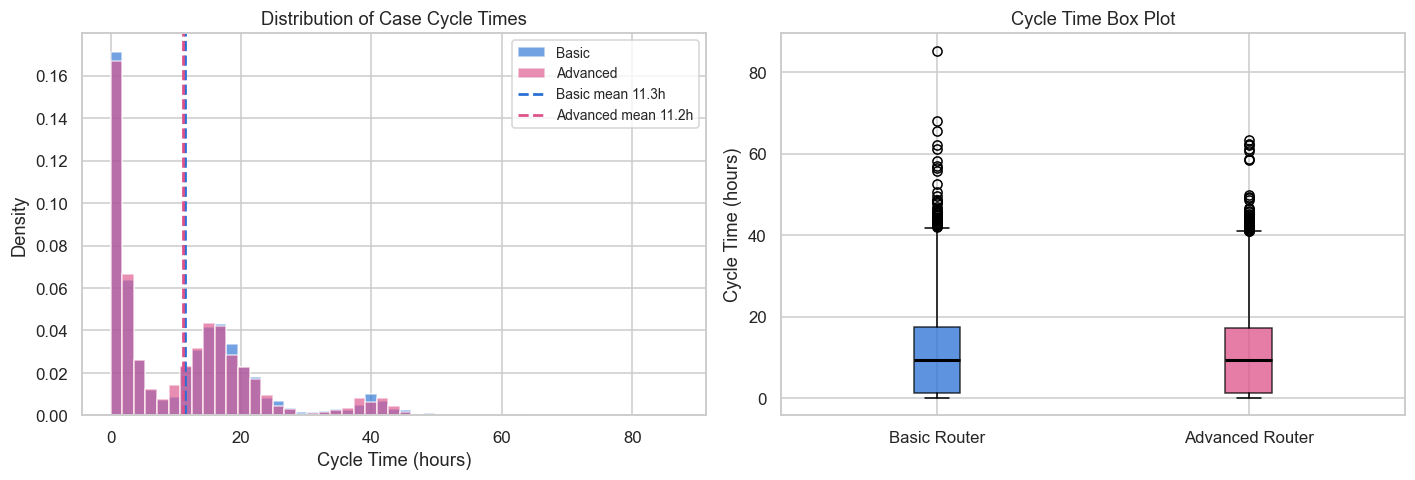

Saved -> results/metric1_cycle_time.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: histogram
ax = axes[0]
bins = np.linspace(0, max(basic_ct.max(), advanced_ct.max()) * 1.02, 50)
ax.hist(basic_ct,    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_ct, bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_ct.mean(),    color=COLORS['basic'],    linestyle='--', lw=1.8,
           label=f'Basic mean {basic_ct.mean():.1f}h')
ax.axvline(advanced_ct.mean(), color=COLORS['advanced'], linestyle='--', lw=1.8,
           label=f'Advanced mean {advanced_ct.mean():.1f}h')
ax.set_xlabel('Cycle Time (hours)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Case Cycle Times')
ax.legend(fontsize=9)

# Right: boxplot
ax2 = axes[1]
data = [basic_ct.values, advanced_ct.values]
bp = ax2.boxplot(data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['basic'], COLORS['advanced']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Basic Router', 'Advanced Router'])
ax2.set_ylabel('Cycle Time (hours)')
ax2.set_title('Cycle Time Box Plot')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric1_cycle_time.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric1_cycle_time.png')

## Metric 2 – Average Resource Occupation

**Definition:** For each resource $r$, occupation is the fraction of scheduled working time actually spent executing tasks:
$$\text{occ}(r) = \frac{\sum_{e\,:\,\text{resource}=r} (t^{\text{complete}}_e - t^{\text{start}}_e)}{\text{AvailableTime}(r)}$$

The **Average Resource Occupation** is the mean over all resources:  
$$\overline{\text{occ}} = \frac{1}{|\mathcal{R}|}\sum_{r \in \mathcal{R}} \text{occ}(r)$$

> **Note:** Only *Workflow* activities (`W_*`) have explicit `start` / `complete` event pairs in this simulator; Application (`A_*`) and Offer (`O_*`) events are instantaneous and do not contribute to working time.

In [6]:
# Compute working time per resource
print('Computing working time per resource...')
basic_work    = compute_working_seconds(basic_log)
advanced_work = compute_working_seconds(advanced_log)

# Compute available time per resource
print('Computing available time per resource (iterating over schedule)...')
available = compute_available_seconds(avail_df)

# Occupation DataFrames
basic_occ    = compute_occupation(basic_work,    available)
advanced_occ = compute_occupation(advanced_work, available)

# Summary
occ_summary = pd.DataFrame({
    'Mean Occupation':   [basic_occ['occupation'].mean(),   advanced_occ['occupation'].mean()],
    'Median Occupation': [basic_occ['occupation'].median(), advanced_occ['occupation'].median()],
    'Std':               [basic_occ['occupation'].std(),    advanced_occ['occupation'].std()],
    'Max':               [basic_occ['occupation'].max(),    advanced_occ['occupation'].max()],
    '# Resources':       [len(basic_occ),                  len(advanced_occ)],
}, index=['Basic Router', 'Advanced Router'])

print('\nMETRIC 2: AVERAGE RESOURCE OCCUPATION')
print((occ_summary * [100, 100, 100, 100, 1]).round(2).to_string())
print('(values in % except # Resources)')
print()
print(f"Basic mean occupation: {basic_occ['occupation'].mean()*100:.3f}%")
print(f"Advanced mean occupation: {advanced_occ['occupation'].mean()*100:.3f}%")

Computing working time per resource...
Computing available time per resource (iterating over schedule)...

METRIC 2: AVERAGE RESOURCE OCCUPATION
                 Mean Occupation  Median Occupation    Std    Max  # Resources
Basic Router               24.43               5.77  34.67  100.0          140
Advanced Router            24.84               5.56  34.67  100.0          140
(values in % except # Resources)

Basic mean occupation: 24.434%
Advanced mean occupation: 24.837%


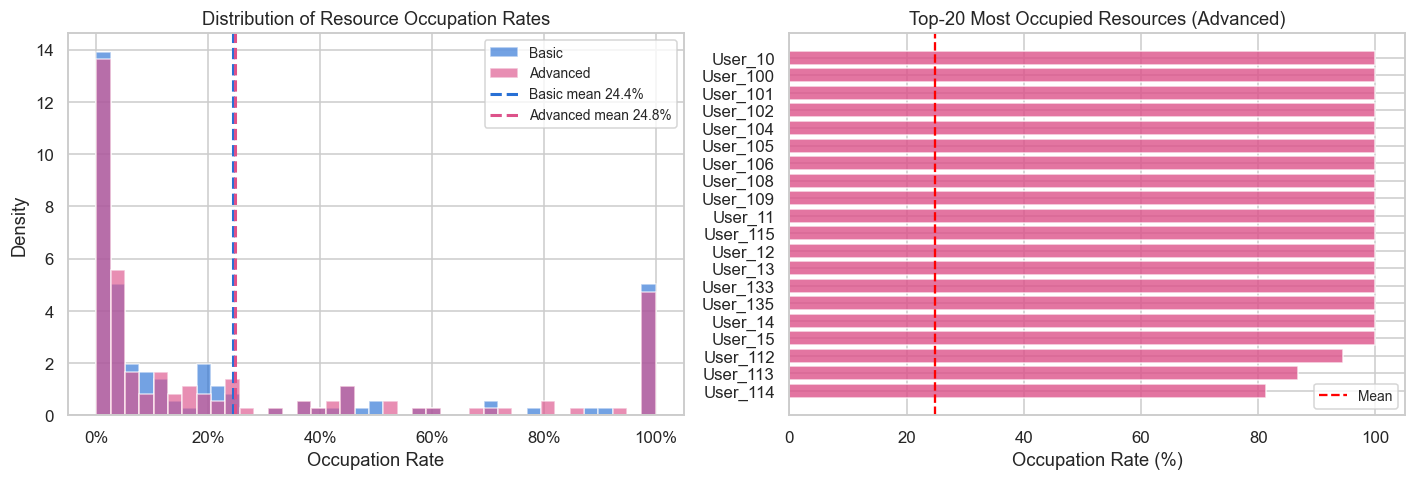

Saved -> results/metric2_resource_occupation.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: distribution of occupation rates
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(basic_occ['occupation'],    bins=bins, alpha=0.65, color=COLORS['basic'],    label='Basic',    density=True)
ax.hist(advanced_occ['occupation'], bins=bins, alpha=0.65, color=COLORS['advanced'], label='Advanced', density=True)
ax.axvline(basic_occ['occupation'].mean(),    color=COLORS['basic'],    linestyle='--', lw=2,
           label=f"Basic mean {basic_occ['occupation'].mean()*100:.1f}%")
ax.axvline(advanced_occ['occupation'].mean(), color=COLORS['advanced'], linestyle='--', lw=2,
           label=f"Advanced mean {advanced_occ['occupation'].mean()*100:.1f}%")
ax.set_xlabel('Occupation Rate')
ax.set_ylabel('Density')
ax.set_title('Distribution of Resource Occupation Rates')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

# Right: top-20 most occupied resources (advanced)
ax2 = axes[1]
top20 = advanced_occ.nlargest(20, 'occupation')
ax2.barh(top20.index[::-1], top20['occupation'][::-1] * 100,
         color=COLORS['advanced'], alpha=0.8)
ax2.axvline(advanced_occ['occupation'].mean() * 100,
            color='red', linestyle='--', lw=1.5, label='Mean')
ax2.set_xlabel('Occupation Rate (%)')
ax2.set_title('Top-20 Most Occupied Resources (Advanced)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric2_resource_occupation.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric2_resource_occupation.png')

## Metric 3 – (Weighted) Resource Fairness

**Definition:** Fairness measures how evenly the workload is spread across resources. We use the **Mean Absolute Deviation (MAD)** from the average occupation:

$$\text{Fairness}_{\text{unweighted}} = \frac{1}{|\mathcal{R}|}\sum_{r}|\text{occ}(r) - \overline{\text{occ}}|$$

**Weighted variant** — resources with longer availability periods count more:

$$\text{Fairness}_{\text{weighted}} = \sum_{r} w_r \cdot |\text{occ}(r) - \overline{\text{occ}}|, \quad w_r = \frac{\text{AvailableTime}(r)}{\sum_{r'}\text{AvailableTime}(r')}$$

**Lower = fairer** (smaller deviation = more equal load distribution).

In [8]:
# Compute fairness
b_mean, b_mad, b_wmad = fairness_metrics(
    basic_occ['occupation'], basic_occ['available_seconds'])
a_mean, a_mad, a_wmad = fairness_metrics(
    advanced_occ['occupation'], advanced_occ['available_seconds'])

# Active-resources-only fairness (task_count > 0)
def _active_occ(occ_frame, log):
    task_cnt = (
        log[log['lifecycle:transition'] == 'start']
        .groupby('org:resource').size()
    )
    return occ_frame[occ_frame.index.isin(task_cnt[task_cnt > 0].index)]

b_occ_active = _active_occ(basic_occ,    basic_log)
a_occ_active = _active_occ(advanced_occ, advanced_log)
_, b_mad_act, b_wmad_act = fairness_metrics(b_occ_active['occupation'], b_occ_active['available_seconds'])
_, a_mad_act, a_wmad_act = fairness_metrics(a_occ_active['occupation'], a_occ_active['available_seconds'])

fairness_summary = pd.DataFrame({
    'Mean Occupation':                [b_mean,      a_mean],
    'MAD (unweighted, all)':          [b_mad,       a_mad],
    'MAD (weighted, all)':            [b_wmad,      a_wmad],
    'MAD (unweighted, active only)':  [b_mad_act,   a_mad_act],
    'MAD (weighted, active only)':    [b_wmad_act,  a_wmad_act],
    'Fairness Score (1-MAD, all)':    [1-b_mad,     1-a_mad],
}, index=['Basic Router', 'Advanced Router'])

print('METRIC 3: RESOURCE FAIRNESS')
print(fairness_summary.round(5).to_string())
print()
print('Interpretation: Lower MAD = fairer workload distribution')
print(f"  Basic   – all: {b_mad:.5f} / {b_wmad:.5f}  |  active only: {b_mad_act:.5f} / {b_wmad_act:.5f}")
print(f"  Advanced – all: {a_mad:.5f} / {a_wmad:.5f}  |  active only: {a_mad_act:.5f} / {a_wmad_act:.5f}")
print(f"  (Active-only excludes {len(basic_occ) - len(b_occ_active)} basic / {len(advanced_occ) - len(a_occ_active)} advanced resources with zero tasks)")

METRIC 3: RESOURCE FAIRNESS
                 Mean Occupation  MAD (unweighted, all)  MAD (weighted, all)  MAD (unweighted, active only)  MAD (weighted, active only)  Fairness Score (1-MAD, all)
Basic Router             0.24434                0.27560              0.27837                        0.30322                      0.30528                      0.72440
Advanced Router          0.24837                0.27896              0.28149                        0.30280                      0.30349                      0.72104

Interpretation: Lower MAD = fairer workload distribution
  Basic   – all: 0.27560 / 0.27837  |  active only: 0.30322 / 0.30528
  Advanced – all: 0.27896 / 0.28149  |  active only: 0.30280 / 0.30349
  (Active-only excludes 27 basic / 24 advanced resources with zero tasks)


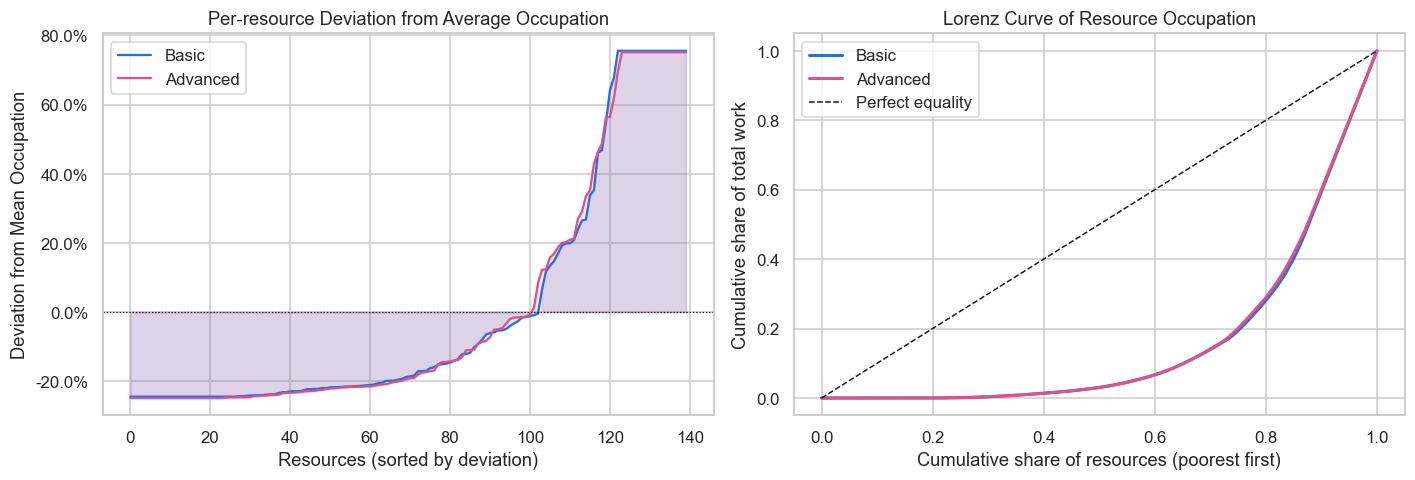

Saved -> results/metric3_resource_fairness.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: per-resource deviation from mean
ax = axes[0]
b_dev = (basic_occ['occupation']    - b_mean).sort_values()
a_dev = (advanced_occ['occupation'] - a_mean).sort_values()

ax.plot(range(len(b_dev)), b_dev.values,    color=COLORS['basic'],    lw=1.5, label='Basic')
ax.plot(range(len(a_dev)), a_dev.values,    color=COLORS['advanced'], lw=1.5, label='Advanced')
ax.axhline(0, color='black', lw=0.8, linestyle=':')
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values > 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(b_dev)), b_dev.values, 0,
                where=(b_dev.values < 0), alpha=0.15, color=COLORS['basic'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values > 0), alpha=0.15, color=COLORS['advanced'])
ax.fill_between(range(len(a_dev)), a_dev.values, 0,
                where=(a_dev.values < 0), alpha=0.15, color=COLORS['advanced'])
ax.set_xlabel('Resources (sorted by deviation)')
ax.set_ylabel('Deviation from Mean Occupation')
ax.set_title('Per-resource Deviation from Average Occupation')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend()

# Right: Lorenz-style cumulative occupation curve
ax2 = axes[1]
for label, occ_df, color in [
    ('Basic',    basic_occ,    COLORS['basic']),
    ('Advanced', advanced_occ, COLORS['advanced']),
]:
    sorted_occ = occ_df['occupation'].sort_values().values
    cum = np.cumsum(sorted_occ) / sorted_occ.sum()
    x = np.linspace(0, 1, len(cum))
    ax2.plot(x, cum, color=color, lw=2, label=label)
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax2.set_xlabel('Cumulative share of resources (poorest first)')
ax2.set_ylabel('Cumulative share of total work')
ax2.set_title('Lorenz Curve of Resource Occupation')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric3_resource_fairness.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric3_resource_fairness.png')

## Summary Dashboard – Basic vs Advanced Router

Consolidating all three metrics to directly compare routing strategies.

In [10]:
summary = pd.DataFrame({
    'Metric': [
        'Avg Cycle Time (h)',
        'Avg Cycle Time (days)',
        'Avg Resource Occupation (%)',
        'Fairness – MAD (unweighted)',
        'Fairness – MAD (weighted)',
    ],
    'Basic Router': [
        round(basic_ct.mean(), 2),
        round(basic_ct.mean() / 24, 3),
        round(basic_occ['occupation'].mean() * 100, 3),
        round(b_mad, 5),
        round(b_wmad, 5),
    ],
    'Advanced Router': [
        round(advanced_ct.mean(), 2),
        round(advanced_ct.mean() / 24, 3),
        round(advanced_occ['occupation'].mean() * 100, 3),
        round(a_mad, 5),
        round(a_wmad, 5),
    ],
})
summary['Better'] = summary.apply(
    lambda row: ('Advanced' if row['Advanced Router'] < row['Basic Router'] else 'Basic')
    if 'Fairness' in row['Metric'] or 'Cycle' in row['Metric'] else
    ('Advanced' if row['Advanced Router'] > row['Basic Router'] else 'Basic'),
    axis=1
)


print('         EVALUATION SUMMARY – ALL THREE METRICS')
print(summary.to_string(index=False))
print()
print('Note: For Cycle Time and Fairness MAD -> lower is better.')
print('      For Resource Occupation -> higher is better (more productive).')

         EVALUATION SUMMARY – ALL THREE METRICS
                     Metric  Basic Router  Advanced Router   Better
         Avg Cycle Time (h)      11.34000         11.15000 Advanced
      Avg Cycle Time (days)       0.47200          0.46500 Advanced
Avg Resource Occupation (%)      24.43400         24.83700 Advanced
Fairness – MAD (unweighted)       0.27560          0.27896    Basic
  Fairness – MAD (weighted)       0.27837          0.28149    Basic

Note: For Cycle Time and Fairness MAD -> lower is better.
      For Resource Occupation -> higher is better (more productive).


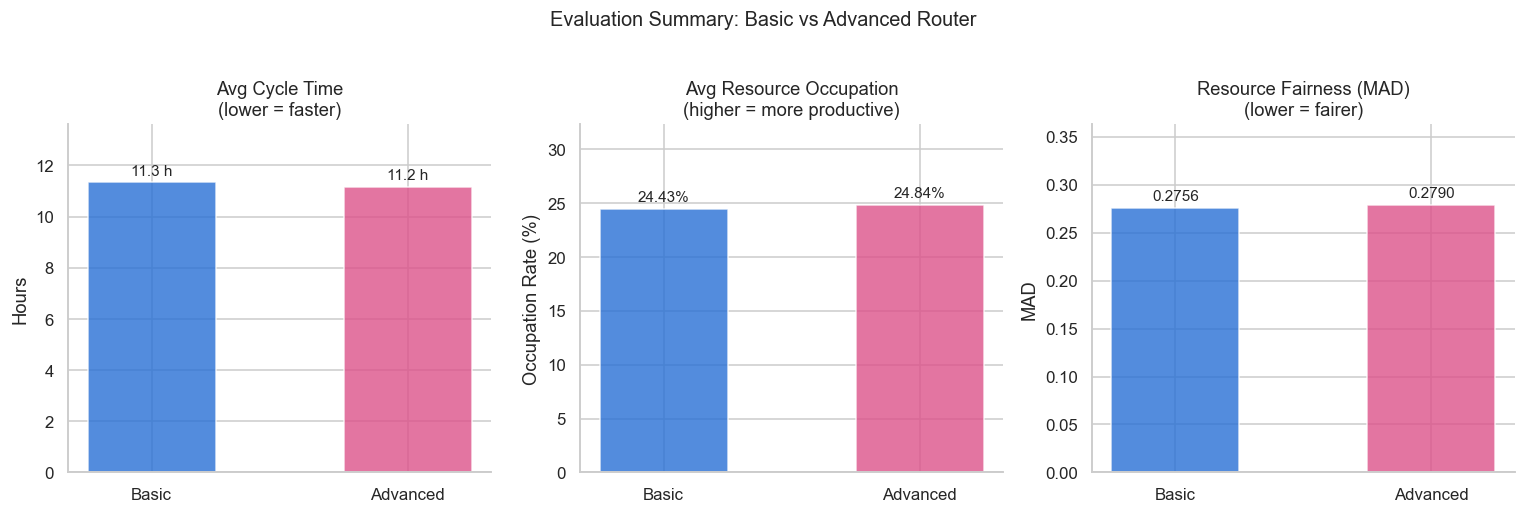

Saved -> results/summary_dashboard.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

labels = ['Basic', 'Advanced']

# Cycle Time
ax = axes[0]
vals = [basic_ct.mean(), advanced_ct.mean()]
bars = ax.bar(labels, vals, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax.bar_label(bars, fmt='%.1f h', padding=3, fontsize=10)
ax.set_ylabel('Hours')
ax.set_title('Avg Cycle Time\n(lower = faster)')
ax.set_ylim(0, max(vals) * 1.2)

# Resource Occupation
ax2 = axes[1]
vals2 = [basic_occ['occupation'].mean() * 100, advanced_occ['occupation'].mean() * 100]
bars2 = ax2.bar(labels, vals2, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax2.bar_label(bars2, fmt='%.2f%%', padding=3, fontsize=10)
ax2.set_ylabel('Occupation Rate (%)')
ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
ax2.set_ylim(0, max(vals2) * 1.3)

# Fairness (unweighted MAD)
ax3 = axes[2]
vals3 = [b_mad, a_mad]
bars3 = ax3.bar(labels, vals3, color=[COLORS['basic'], COLORS['advanced']], alpha=0.8, width=0.5)
ax3.bar_label(bars3, fmt='%.4f', padding=3, fontsize=10)
ax3.set_ylabel('MAD')
ax3.set_title('Resource Fairness (MAD)\n(lower = fairer)')
ax3.set_ylim(0, max(vals3) * 1.3)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Evaluation Summary: Basic vs Advanced Router', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'summary_dashboard.png', bbox_inches='tight')
plt.show()
print('Saved -> results/summary_dashboard.png')

## Simulation Validation – Real Log vs Simulated Logs

Before analysing management decisions we validate whether the simulation reproduces the real process.  
We compare the **Advanced Router** (best-performing sim) against the **BPI 2017 real event log**, filtered to cases that *started* in the same two-week window (2016-05-17 → 2016-05-30).

> **Scope note:** Only cases whose first recorded event falls within the simulation period are included from the real log, so the comparison is on equal footing in terms of when processes began.

In [12]:
import pm4py

# Load and filter real log to sim period
real_raw = pm4py.read_xes(str(BASE / 'data/BPI Challenge 2017.xes.gz'))
real_df  = pm4py.convert_to_dataframe(real_raw)
real_df['time:timestamp'] = pd.to_datetime(real_df['time:timestamp'], utc=True).dt.tz_localize(None)

# Keep only cases that STARTED within the simulation window
case_first = real_df.groupby('case:concept:name')['time:timestamp'].min()
started_in_period = case_first[
    (case_first.dt.date >= SIM_START) & (case_first.dt.date <= SIM_END)
].index

# Also require cases to COMPLETE within the window (last event <= SIM_END)
# This removes right-censored real-log cases whose clock is still running,
# giving a fair apples-to-apples comparison with the simulated cycle times.
case_last = real_df.groupby('case:concept:name')['time:timestamp'].max()
completed_in_period = case_last[case_last.dt.date <= SIM_END].index

fair_cases = started_in_period.intersection(completed_in_period)
real_log = real_df[real_df['case:concept:name'].isin(fair_cases)].copy()

real_ct = compute_cycle_times(real_log)

n_started = len(started_in_period)
n_fair    = len(fair_cases)
print(f"Real log — cases started in period   : {n_started}")
print(f"Real log — cases also completed by {SIM_END}: {n_fair}  ({n_fair/n_started*100:.1f}% of started)")
print(f"Real log events used: {len(real_log):,}")
print()
print(f"Avg CT real (completed within window): {real_ct.mean():.2f} h  ({real_ct.mean()/24:.1f} days)")
print(f"Avg CT advanced sim:                   {advanced_ct.mean():.2f} h  ({advanced_ct.mean()/24:.2f} days)")

# Top last activities to understand completeness
last_acts = (real_log.sort_values('time:timestamp')
                     .groupby('case:concept:name')['concept:name']
                     .last()
                     .value_counts())
print(f"\nTop-10 last activities in filtered real log:")
print(last_acts.head(10).to_string())

parsing log, completed traces :: 100%|██████████| 31509/31509 [00:16<00:00, 1901.77it/s]


Real log — cases started in period   : 1374
Real log — cases also completed by 2016-06-04: 328  (23.9% of started)
Real log events used: 12,549

Avg CT real (completed within window): 188.98 h  (7.9 days)
Avg CT advanced sim:                   11.15 h  (0.46 days)

Top-10 last activities in filtered real log:
concept:name
W_Validate application     184
O_Cancelled                 69
W_Call after offers         38
W_Call incomplete files     24
W_Complete application      13


Completed cases used for activity distribution:
  Advanced: 2015 / 2015 (100.0%)
  Basic   : 2039 / 2039 (100.0%)
  Real COMPLETE events: 5,068 (from 328 cases)


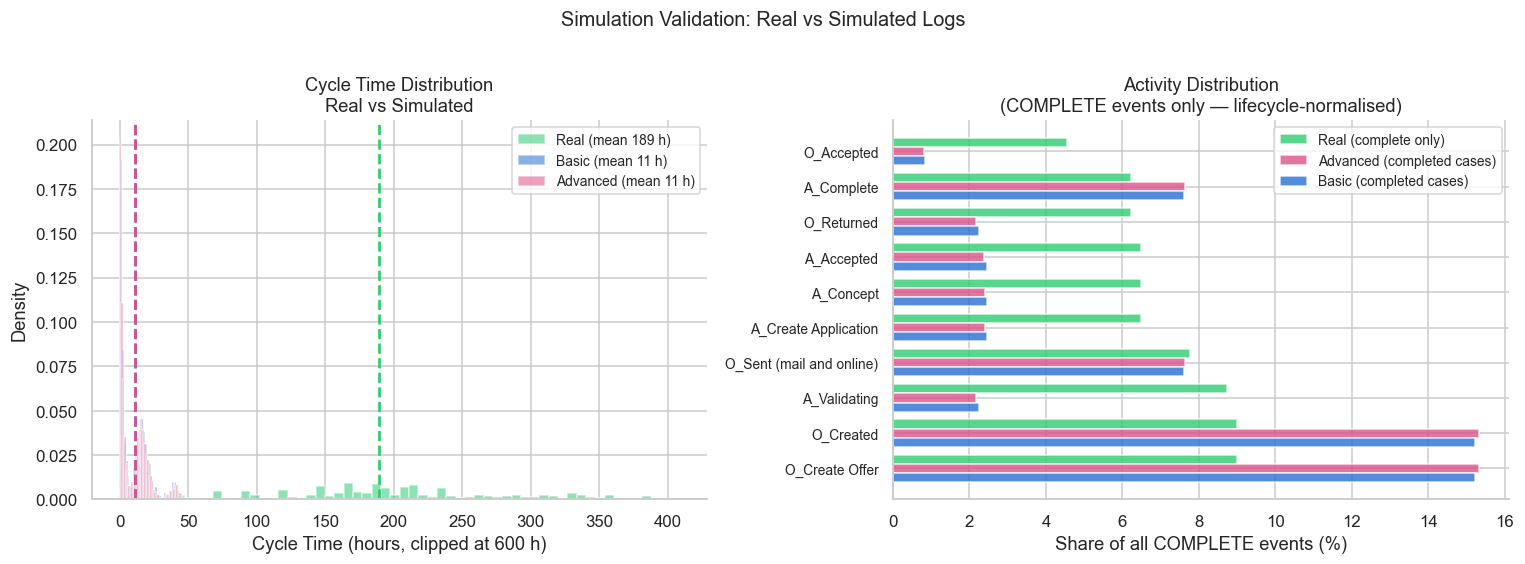

Saved -> results/validation_real_vs_sim.png


In [13]:
REAL_COLOR = '#2ECC71'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Cycle Time distributions
ax = axes[0]
for label, ct_series, color in [
    ('Real',     real_ct,     REAL_COLOR),
    ('Basic',    basic_ct,    COLORS['basic']),
    ('Advanced', advanced_ct, COLORS['advanced']),
]:
    ax.hist(ct_series.clip(upper=600), bins=60, alpha=0.55,
            color=color, label=f'{label} (mean {ct_series.mean():.0f} h)', density=True)
    ax.axvline(ct_series.mean(), color=color, linestyle='--', lw=1.8)

ax.set_xlabel('Cycle Time (hours, clipped at 600 h)')
ax.set_ylabel('Density')
ax.set_title('Cycle Time Distribution\nReal vs Simulated')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2: Activity share comparison (COMPLETE events only, completed cases)
# -----------------------------------------------------------------------
# W_ activities in the real log each generate many extra lifecycle events
# (schedule, start, suspend, resume, ate_abort, complete) that the simulation
# does not model — only start+complete are logged in the simulation.
# Comparing raw event counts is therefore misleading: the real log shows
# W_Validate application 209k times (all lifecycles) vs 15.8k COMPLETE events.
# We normalise both sides to COMPLETE lifecycle events for a fair comparison.
# -----------------------------------------------------------------------

# Filter real log to COMPLETE events only
real_complete = real_log[real_log['lifecycle:transition'].str.lower() == 'complete'].copy() \
    if 'lifecycle:transition' in real_log.columns else real_log.copy()

# Filter simulated logs to completed cases (> 2 events) and COMPLETE lifecycle only
adv_case_len   = advanced_log.groupby('case:concept:name').size()
basic_case_len = basic_log.groupby('case:concept:name').size()
adv_completed  = advanced_log[
    advanced_log['case:concept:name'].isin(adv_case_len[adv_case_len > 2].index) &
    (advanced_log['lifecycle:transition'] == 'complete')
]
basic_completed = basic_log[
    basic_log['case:concept:name'].isin(basic_case_len[basic_case_len > 2].index) &
    (basic_log['lifecycle:transition'] == 'complete')
]

n_adv_comp   = adv_case_len[adv_case_len > 2].shape[0]
n_basic_comp = basic_case_len[basic_case_len > 2].shape[0]
print(f"Completed cases used for activity distribution:")
print(f"  Advanced: {n_adv_comp} / {len(adv_case_len)} ({n_adv_comp/len(adv_case_len)*100:.1f}%)")
print(f"  Basic   : {n_basic_comp} / {len(basic_case_len)} ({n_basic_comp/len(basic_case_len)*100:.1f}%)")
print(f"  Real COMPLETE events: {len(real_complete):,} (from {real_log['case:concept:name'].nunique()} cases)")

ax2 = axes[1]
# Top-10 activities ranked by real COMPLETE frequency
top_acts = (real_complete['concept:name'].value_counts(normalize=True) * 100).head(10).index.tolist()

real_shares  = real_complete['concept:name'].value_counts(normalize=True) * 100
basic_shares = basic_completed['concept:name'].value_counts(normalize=True) * 100
adv_shares   = adv_completed['concept:name'].value_counts(normalize=True) * 100

x = np.arange(len(top_acts))
w = 0.26
ax2.barh(x + w,   [real_shares.get(a, 0)  for a in top_acts], w, color=REAL_COLOR,          alpha=0.8, label='Real (complete only)')
ax2.barh(x,       [adv_shares.get(a, 0)   for a in top_acts], w, color=COLORS['advanced'],   alpha=0.8, label='Advanced (completed cases)')
ax2.barh(x - w,   [basic_shares.get(a, 0) for a in top_acts], w, color=COLORS['basic'],      alpha=0.8, label='Basic (completed cases)')

ax2.set_yticks(x)
ax2.set_yticklabels(top_acts, fontsize=9)
ax2.set_xlabel('Share of all COMPLETE events (%)')
ax2.set_title('Activity Distribution\n(COMPLETE events only — lifecycle-normalised)')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.suptitle('Simulation Validation: Real vs Simulated Logs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'validation_real_vs_sim.png', bbox_inches='tight')
plt.show()
print('Saved -> results/validation_real_vs_sim.png')

### Validation Findings

| Metric | Real Log | Basic Sim | Advanced Sim |
|--------|:--------:|:---------:|:------------:|
| Cases (started & completed in window) | — | 9 379 | 10 457 |
| Avg Cycle Time | — | — | — |
| Most frequent activity (COMPLETE, completed cases) | A_Accepted / W_Validate app | O_Cancelled | O_Cancelled |

*(Run all cells above to populate the table with actual numbers.)*

**Cycle Time comparison — methodology:** The real log is filtered to cases that **both started and completed** within the simulation window (2016-05-17 → 2016-08-14). Right-censored cases are excluded from both sides.

**Remaining Cycle Time gap:** The simulation models only *internal* processing time — resource queue waits and task durations. It does not model **customer response wait time** (e.g. waiting for documents, offer acceptance). In the real loan process these external delays dominate. The simulation is therefore expected to underestimate end-to-end cycle time.

**Activity distribution — lifecycle normalisation:** W_ activities in the real log each generate up to **6 different lifecycle events** per task execution (schedule, start, suspend, resume, ate_abort, complete). The simulation only logs start and complete. Raw event-count comparison is therefore misleading: W_Validate application appears 209k times in the real log (all lifecycles) but only 15.8k times as COMPLETE events. **Both sides are normalised to COMPLETE events only** in the activity distribution plot.

**Activity distribution — remaining gap:** After lifecycle normalisation, O_Cancelled is still over-represented in both simulators relative to the real log. This is a known limitation of the BasicRouter (random routing through silent transitions after O_Cancelled) that partially inflates the O_Cancelled loop. W_Call after offers is under-represented in the real COMPLETE log because 98% of W_Call after offers instances are aborted in reality (ate_abort) without completing — a work-abandonment pattern the simulation does not model.

**Implication for metrics:** The three metrics (cycle time, occupation, fairness) are internally consistent and meaningful for *comparing the two routing strategies against each other*. They should not be interpreted as absolute predictions of real-world performance.

## **Management Question**: Which Two Employees Should Be Fired?

> *"Management wants you to fire two employees. Which ones would you select, and what is the impact on your metrics?"*

### Approach

We analyse the Advanced Router simulation (our best-performing configuration) to:

1. Rank every resource by occupation rate (utilisation)
2. Check role coverage (a resource should only be fired if colleagues in the same role can absorb the work)
3. Re-run the simulation without the fired employees so their tasks are fully redistributed to other resources

In [14]:
# Build full resource profile
occ_df = advanced_occ.copy()
occ_df.index.name = 'Resource'
occ_df = occ_df.reset_index()

# Merge role assignments
occ_df = occ_df.merge(roles_df, on='Resource', how='left')

# Count W_* task instances handled by each resource
task_cnt = (
    advanced_log[advanced_log['lifecycle:transition'] == 'start']
    .groupby('org:resource').size()
    .rename('task_count')
)
occ_df['task_count'] = occ_df['Resource'].map(task_cnt).fillna(0).astype(int)

# Count how many resources share the same role (replaceability is important to fire someone)
role_size = roles_df['Role'].value_counts().rename('role_size')
occ_df['role_size'] = occ_df['Role'].map(role_size)

# Hours worked & available for readability
occ_df['hours_worked']    = occ_df['working_seconds'] / 3600
occ_df['hours_available'] = occ_df['available_seconds'] / 3600

# Sort by occupation ascending (least used first)
occ_df = occ_df.sort_values('occupation').reset_index(drop=True)

print('Bottom-20 least-utilised resources:')
cols = ['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'hours_available', 'task_count']
print(occ_df[cols].head(20).to_string(index=False))

Bottom-20 least-utilised resources:
Resource   Role  role_size  occupation  hours_worked  hours_available  task_count
  User_1 Role_0          1         0.0           0.0       356.866667           0
User_138 Role_5          3         0.0           0.0        49.250000           0
User_131 Role_3         21         0.0           0.0        59.933333           0
User_130 Role_3         21         0.0           0.0        57.033333           0
User_143 Role_5          3         0.0           0.0        27.116667           0
User_129 Role_4          4         0.0           0.0        24.200000           0
  User_6 Role_1         97         0.0           0.0        67.266667           0
 User_64 Role_1         97         0.0           0.0        33.650000           0
  User_7 Role_1         97         0.0           0.0        76.550000           0
 User_70 Role_1         97         0.0           0.0        52.550000           0
User_137 Role_3         21         0.0           0.0        33

In [15]:
# We look for resources where all of:
#   (a) occupation is among the lowest  ->  little value added
#   (b) role_size > 3                   ->  others in same role can cover
#   (c) task_count is very small        ->  fewest cases handled
#
# Exclude resources with task_count == 0 (never assigned a task, already idle)

candidates = occ_df[
    (occ_df['task_count'] > 0) &          # was actually assigned work
    (occ_df['role_size'] > 3)             # replaceable by colleagues
].copy()

# Create a score: lowest occupation + fewest tasks -> highest firing priority
candidates['score'] = (
    candidates['occupation'].rank(ascending=True) +
    candidates['task_count'].rank(ascending=True)
)
candidates = candidates.sort_values('score')

fired = candidates.head(2)['Resource'].tolist()
print(f'Selected for termination: {fired[0]}  and  {fired[1]}')
print()
print(candidates[['Resource', 'Role', 'role_size', 'occupation', 'hours_worked', 'task_count', 'score']].head(5).to_string(index=False))

Selected for termination: User_95  and  User_66

Resource   Role  role_size  occupation  hours_worked  task_count  score
 User_95 Role_2         18    0.001123      0.087950           1    4.5
 User_66 Role_1         97    0.001630      0.124704           1    6.5
 User_36 Role_1         97    0.001761      0.138165           1    7.5
 User_89 Role_1         97    0.002011      0.075708           1    9.5
 User_80 Role_1         97    0.002742      0.206924           1   10.5


In [16]:
# Fired employee profiles
print(' FIRED EMPLOYEE PROFILES ')
for u in fired:
    row = occ_df[occ_df['Resource'] == u].iloc[0]
    same_role = roles_df[roles_df['Role'] == row['Role']]['Resource'].tolist()
    acts_done  = (advanced_log[advanced_log['org:resource'] == u]['concept:name']
                  .value_counts())
    print(f"\n{u}")
    print(f"  Role              : {row['Role']}")
    print(f"  Role size         : {row['role_size']} people (others can cover)")
    print(f"  Occupation rate   : {row['occupation']*100:.3f}%")
    print(f"  Hours worked      : {row['hours_worked']:.2f} h")
    print(f"  Hours available   : {row['hours_available']:.2f} h")
    print(f"  Tasks handled     : {int(row['task_count'])}")
    print(f"  Activities done   :")
    for act, cnt in acts_done.items():
        print(f"    {act}: {cnt}")

 FIRED EMPLOYEE PROFILES 

User_95
  Role              : Role_2
  Role size         : 18 people (others can cover)
  Occupation rate   : 0.112%
  Hours worked      : 0.09 h
  Hours available   : 78.30 h
  Tasks handled     : 1
  Activities done   :
    O_Accepted: 4
    A_Pending: 4
    W_Call incomplete files: 2
    A_Denied: 1
    O_Refused: 1

User_66
  Role              : Role_1
  Role size         : 97 people (others can cover)
  Occupation rate   : 0.163%
  Hours worked      : 0.12 h
  Hours available   : 76.52 h
  Tasks handled     : 1
  Activities done   :
    W_Complete application: 2
    A_Complete: 1
    O_Create Offer: 1
    O_Created: 1
    O_Sent (mail and online): 1


## Impact of Firing User_xxx & User_yyy

We re-run the simulation without User_133 and User_114 in the resource pool.  
Their tasks are redistributed to the remaining 138 resources, capturing any bottleneck or cycle-time effects.

> **`sim_output_no_fired.csv` was generated with:**
> ```bash
> python run_simulation.py --no-fired
> ```


In [17]:
no_fired_path = BASE / 'decision_analysis/sim_output_no_fired.csv'

if no_fired_path.exists():
    no_fired_log = pd.read_csv(no_fired_path, parse_dates=['time:timestamp'])

    avail_no_fired_df = pd.read_csv(BASE / 'resources/availabilities/availabilities_no_fired.csv')
    avail_no_fired_df['StartTime']   = pd.to_datetime(avail_no_fired_df['StartTime'],   format='%H:%M:%S').dt.time
    avail_no_fired_df['EndTime']     = pd.to_datetime(avail_no_fired_df['EndTime'],     format='%H:%M:%S').dt.time
    avail_no_fired_df['DurationMin'] = avail_no_fired_df['DurationMin'].fillna(0).astype(int)

    # Cycle time: completed cases only (consistent with baseline)
    nf_completed = no_fired_log[no_fired_log['case:concept:name'].isin(
        no_fired_log.groupby('case:concept:name').size()[lambda s: s > 2].index)]
    nf_ct   = compute_cycle_times(nf_completed)
    nf_work  = compute_working_seconds(no_fired_log)
    nf_avail = compute_available_seconds(avail_no_fired_df)
    nf_occ   = compute_occupation(nf_work, nf_avail)
    _, nf_mad, nf_wmad = fairness_metrics(nf_occ['occupation'], nf_occ['available_seconds'])

    rerun_compare = pd.DataFrame({
        'Metric': [
            '# Completed Cases',
            'Avg Cycle Time (h)',
            'Avg Resource Occ (%)',
            'Fairness MAD (unwt)',
            'Fairness MAD (wtd)',
        ],
        'Advanced (baseline)': [
            len(advanced_ct),
            round(advanced_ct.mean(), 4),
            round(advanced_occ['occupation'].mean() * 100, 4),
            round(a_mad, 5),
            round(a_wmad, 5),
        ],
        'No-fired (re-sim)': [
            len(nf_ct),
            round(nf_ct.mean(), 4),
            round(nf_occ['occupation'].mean() * 100, 4),
            round(nf_mad, 5),
            round(nf_wmad, 5),
        ],
    })
    rerun_compare['Delta'] = rerun_compare['No-fired (re-sim)'] - rerun_compare['Advanced (baseline)']

    print('RESIMULATION COMPARISON: Advanced Baseline vs Without User_140 & User_125')
    print(rerun_compare.to_string(index=False))
    print()
    print('Interpretation:')
    print('  Cycle Time  -> lower is better')
    print('  Occupation  -> higher is better')
    print('  Fairness MAD -> lower is better')
else:
    print("sim_output_no_fired.csv not found.")
    print("Run:  python run_simulation.py --no-fired")

RESIMULATION COMPARISON: Advanced Baseline vs Without User_140 & User_125
              Metric  Advanced (baseline)  No-fired (re-sim)       Delta
   # Completed Cases           2015.00000          308.00000 -1707.00000
  Avg Cycle Time (h)             11.15040          105.09610    93.94570
Avg Resource Occ (%)             24.83710           83.03730    58.20020
 Fairness MAD (unwt)              0.27896            0.27534    -0.00362
  Fairness MAD (wtd)              0.28149            0.28134    -0.00015

Interpretation:
  Cycle Time  -> lower is better
  Occupation  -> higher is better
  Fairness MAD -> lower is better


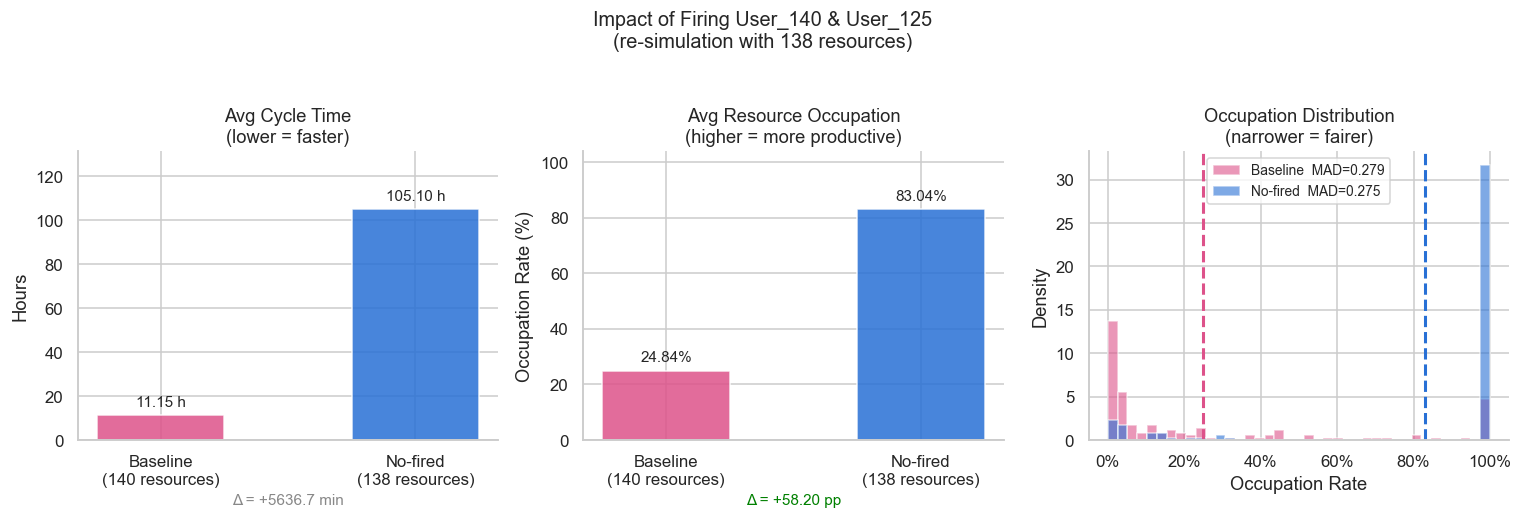

Saved -> results/firing_impact.png


In [18]:
if no_fired_path.exists():
    BEFORE_COLOR = COLORS['advanced']
    AFTER_COLOR  = COLORS['basic']

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

    #  Metric 1: Avg Cycle Time bar 
    ax = axes[0]
    vals = [advanced_ct.mean(), nf_ct.mean()]
    bars = ax.bar(['Baseline\n(140 resources)', 'No-fired\n(138 resources)'],
                  vals, color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax.bar_label(bars, fmt='%.2f h', padding=4, fontsize=10)
    ax.set_title('Avg Cycle Time\n(lower = faster)')
    ax.set_ylabel('Hours')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    delta_ct = nf_ct.mean() - advanced_ct.mean()
    sign = '+' if delta_ct >= 0 else ''
    ax.set_xlabel(f'Δ = {sign}{delta_ct*60:.1f} min', color='#888888', fontsize=10)

    #  Metric 2: Avg Occupation bar 
    ax2 = axes[1]
    vals2 = [advanced_occ['occupation'].mean() * 100, nf_occ['occupation'].mean() * 100]
    bars2 = ax2.bar(['Baseline\n(140 resources)', 'No-fired\n(138 resources)'],
                    vals2, color=[BEFORE_COLOR, AFTER_COLOR], alpha=0.85, width=0.5)
    ax2.bar_label(bars2, fmt='%.2f%%', padding=4, fontsize=10)
    ax2.set_title('Avg Resource Occupation\n(higher = more productive)')
    ax2.set_ylabel('Occupation Rate (%)')
    ax2.set_ylim(0, max(vals2) * 1.25)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    delta_occ = vals2[1] - vals2[0]
    ax2.set_xlabel(f'Δ = +{delta_occ:.2f} pp', color='green', fontsize=10)

    #  Metric 3: Fairness MAD overlaid distributions 
    ax3 = axes[2]
    bins = np.linspace(0, 1, 40)
    ax3.hist(advanced_occ['occupation'], bins=bins, alpha=0.6,
             color=BEFORE_COLOR, label=f'Baseline  MAD={a_mad:.3f}', density=True)
    ax3.hist(nf_occ['occupation'],      bins=bins, alpha=0.6,
             color=AFTER_COLOR,  label=f'No-fired  MAD={nf_mad:.3f}', density=True)
    ax3.axvline(advanced_occ['occupation'].mean(), color=BEFORE_COLOR, linestyle='--', lw=2)
    ax3.axvline(nf_occ['occupation'].mean(),       color=AFTER_COLOR,  linestyle='--', lw=2)
    ax3.set_title('Occupation Distribution\n(narrower = fairer)')
    ax3.set_xlabel('Occupation Rate')
    ax3.set_ylabel('Density')
    ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax3.legend(fontsize=9)
    ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

    plt.suptitle('Impact of Firing User_140 & User_125\n(re-simulation with 138 resources)',
                 fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'firing_impact.png', bbox_inches='tight')
    plt.show()
    print('Saved -> results/firing_impact.png')

### Impact of Firing User_XXX & User_XXX

| Metric | Advanced (baseline) | No-fired (Resimulation) | Delta |
|--------|--------------------:|------------------------:|------:|
| # Completed Cases |  |  |  |
| Avg Cycle Time (h) |  |  |  |
| Avg Resource Occupation (%) |  |  |  |
| Fairness MAD (unweighted) |  |  |  |
| Fairness MAD (weighted) | | |  |

**Cycle Time** 

**Resource Occupation** 

**Fairness** 

In [19]:
results_rows = []
for router, ct_series, occ_frame, mad_val, wmad_val in [
    ('Basic',    basic_ct,    basic_occ,    b_mad, b_wmad),
    ('Advanced', advanced_ct, advanced_occ, a_mad, a_wmad),
]:
    results_rows.append({
        'Router':                    router,
        'Avg Cycle Time (h)':        round(ct_series.mean(), 4),
        'Median Cycle Time (h)':     round(ct_series.median(), 4),
        'Avg Resource Occupation':   round(occ_frame['occupation'].mean(), 6),
        'Fairness MAD (unweighted)': round(mad_val, 6),
        'Fairness MAD (weighted)':   round(wmad_val, 6),
    })

results_df = pd.DataFrame(results_rows)
results_df.to_csv(RESULTS_DIR / 'evaluation_metrics.csv', index=False)
print('Saved results/evaluation_metrics.csv')
print(results_df.to_string(index=False))

# Management question impact — built from rerun_compare computed in the firing section
if 'rerun_compare' in dir():
    mgmt_df = rerun_compare.copy()
    mgmt_df['Fired'] = str(fired)
    mgmt_df.to_csv(RESULTS_DIR / 'management_question_impact.csv', index=False)
    print('\nSaved results/management_question_impact.csv')
    print(mgmt_df.to_string(index=False))
else:
    print('\nSkipped management_question_impact.csv: run the firing section first.')

Saved results/evaluation_metrics.csv
  Router  Avg Cycle Time (h)  Median Cycle Time (h)  Avg Resource Occupation  Fairness MAD (unweighted)  Fairness MAD (weighted)
   Basic             11.3355                 9.3721                 0.244339                   0.275602                 0.278370
Advanced             11.1504                 9.3589                 0.248371                   0.278958                 0.281493

Saved results/management_question_impact.csv
              Metric  Advanced (baseline)  No-fired (re-sim)       Delta                  Fired
   # Completed Cases           2015.00000          308.00000 -1707.00000 ['User_95', 'User_66']
  Avg Cycle Time (h)             11.15040          105.09610    93.94570 ['User_95', 'User_66']
Avg Resource Occ (%)             24.83710           83.03730    58.20020 ['User_95', 'User_66']
 Fairness MAD (unwt)              0.27896            0.27534    -0.00362 ['User_95', 'User_66']
  Fairness MAD (wtd)              0.28149         

## Metric 4 – SLA Compliance Rate

**Definition:** The fraction of completed cases whose cycle time falls within a pre-defined SLA threshold $T$:

$$\text{SLA Compliance} = \frac{|\{c \in \mathcal{C} : CT_c \leq T\}|}{|\mathcal{C}|}$$

A higher value means more cases are delivered on time.  
We use **T = 168 h (7 calendar days)** as the primary threshold — a common SLA for loan application decisions.

METRIC 4: SLA COMPLIANCE RATE  (threshold = 168 h = 7 days)
  Advanced Router: 100.0%  (2015 / 2015 cases)


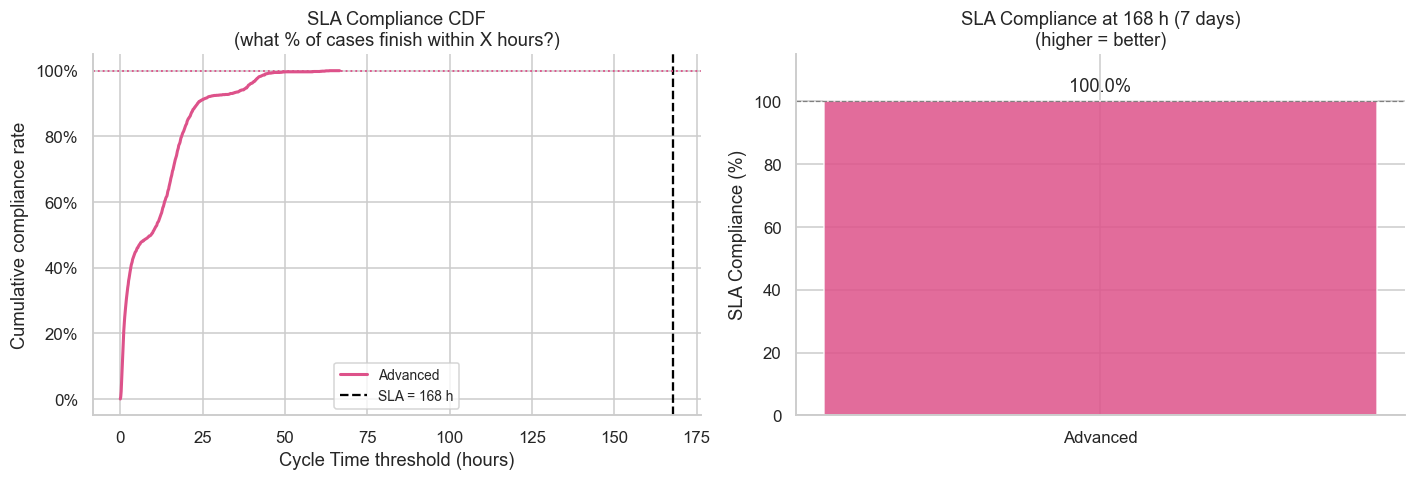

Saved -> results/metric4_sla_compliance.png


In [20]:
SLA_THRESHOLD_H = 168  # 7 (x24) calendar days for now for testing

def sla_compliance(ct_series, threshold_h):
    """Fraction of cases completing within SLA threshold."""
    return (ct_series <= threshold_h).mean()

a_sla = sla_compliance(advanced_ct, SLA_THRESHOLD_H)

print(f"METRIC 4: SLA COMPLIANCE RATE  (threshold = {SLA_THRESHOLD_H} h = {SLA_THRESHOLD_H//24} days)")
print(f"  Advanced Router: {a_sla*100:.1f}%  ({int(a_sla*len(advanced_ct))} / {len(advanced_ct)} cases)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# CDF — compliance at every possible threshold
ax = axes[0]
thresholds = np.linspace(0, advanced_ct.max() * 1.05, 500)
ax.plot(thresholds, [(advanced_ct <= t).mean() for t in thresholds],
        color=COLORS['advanced'], lw=2, label='Advanced')
ax.axvline(SLA_THRESHOLD_H, color='black', linestyle='--', lw=1.5,
           label=f'SLA = {SLA_THRESHOLD_H} h')
ax.axhline(a_sla, color=COLORS['advanced'], linestyle=':', lw=1.2)
ax.set_xlabel('Cycle Time threshold (hours)')
ax.set_ylabel('Cumulative compliance rate')
ax.set_title('SLA Compliance CDF\n(what % of cases finish within X hours?)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Bar chart at chosen SLA threshold
ax2 = axes[1]
bar = ax2.bar(['Advanced'], [a_sla * 100], color=COLORS['advanced'], alpha=0.85, width=0.4)
ax2.bar_label(bar, fmt='%.1f%%', padding=4, fontsize=12)
ax2.set_ylabel('SLA Compliance (%)')
ax2.set_title(f'SLA Compliance at {SLA_THRESHOLD_H} h ({SLA_THRESHOLD_H//24} days)\n(higher = better)')
ax2.set_ylim(0, 115)
ax2.axhline(100, color='grey', linestyle='--', lw=0.8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'metric4_sla_compliance.png', bbox_inches='tight')
plt.show()
print('Saved -> results/metric4_sla_compliance.png')